# Controlling the binomial/Kendall inflation — SNP vs non-SNP (bio1, gen9)

Four ways to de-inflate the raw scans (raw plot-level binomial GIF≈105, Kendall GIF≈9) while keeping signal, each a different ingredient of the LFMM idea. Every panel: QQ (inflation before/after) + Manhattan (what survives). **Two diseases:** pseudoreplication (355 pools = only 31 climate values) and, for the binomial, count over-precision (AF×flowers×2 as independent draws). Latent factors fix structure; overdispersion likelihoods fix the count variance; the honest 31-site unit + a structure null fixes pseudoreplication.

| method | route | GIF after | signal kept | SNP vs non-SNP |
|---|---|---|---|---|
| effective-N binomial +LF16 | binomial | ~1.2 | ✗ nearly killed (1/0 Bonf) | — |
| MSR-null Kendall | rank, 31-site | **~1.3** | ✓ tail (333/127 @p<1e-4, 0 FDR) | **DIFFERENT** ρ=0.34 |
| beta-binomial +LF16 | binomial | ~2.06 | ✓ (13/6 Bonf) | SAME ρ=0.68 |
| latent-factor partial-Spearman | rank, plot | ~2.6 | ✓ (436/280 Bonf) | SAME ρ=0.63 |
| quasi-binomial +LF16 | binomial | ~2.7-2.9 | ✓ (853/616 Bonf) | — |

**Throughline:** every control trades calibration vs power; none hits GIF≈1 *and* keeps strong signal at this unit — the residual ~2× is real pseudoreplication (31 climate values). The 'same vs different' verdict is unit-dependent: plot-level (residual GIF~2-2.7) → SAME; the best-calibrated honest unit (MSR, GIF 1.3) → DIFFERENT, with non-SNP flagging loci SNPs miss (incl. the exact LFMM lead Chr1:13,979,249).

In [1]:
from IPython.display import Image, display

## 1 · Latent-factor partial-Spearman (rank, plot-level, K=16)
The LFMM idea on a **monotone rank** statistic. QQ: raw K=0 (grey, GIF 9.0) far off-diagonal; K=16 (colored, GIF 2.6) pulls down but stays lifted — structure absorbed, residual polygenic/pseudoreplication remains. 436 SNP / 280 non-SNP Bonferroni hits, broad, tall Chr3 peak. This is the test used for the per-axis significant-block table (analytic p reaches significance; GIF-calibrated per axis).

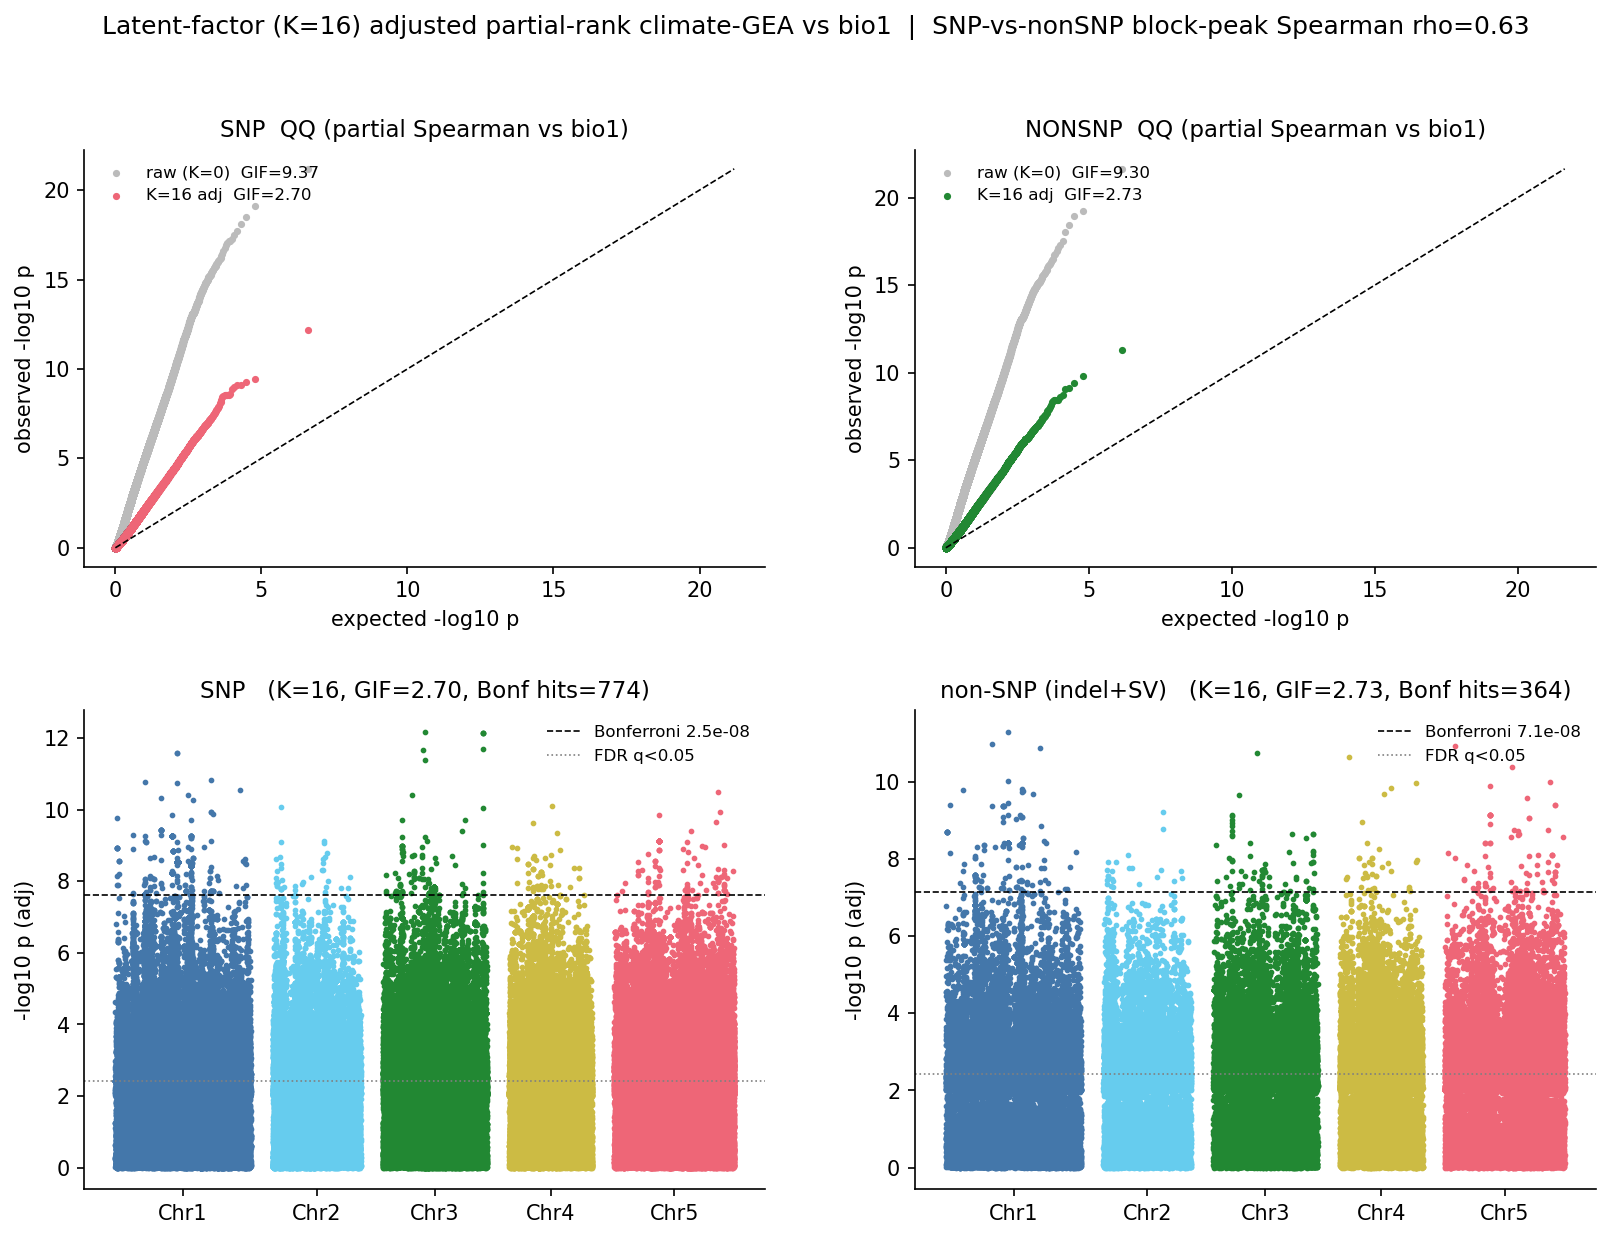

In [2]:
display(Image(filename='/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea_newpanel/lf_rank/lf_rank_qq_manhattan.png'))

## 2 · Structure-preserving MSR-null Kendall (rank, 31-site) — best calibrated
Keep τ/ρ exactly, control structure via a Moran-spectral null over the 31 sites. QQ hugs the diagonal then flattens at the ~1e-4 empirical-p floor; GIF 2.46→**1.30**. But the floor sits *below* Bonferroni → **nothing genome-wide significant** (333/127 @p<1e-4, 0 FDR). Honest but underpowered — and why MSR can't populate a Bonferroni table.

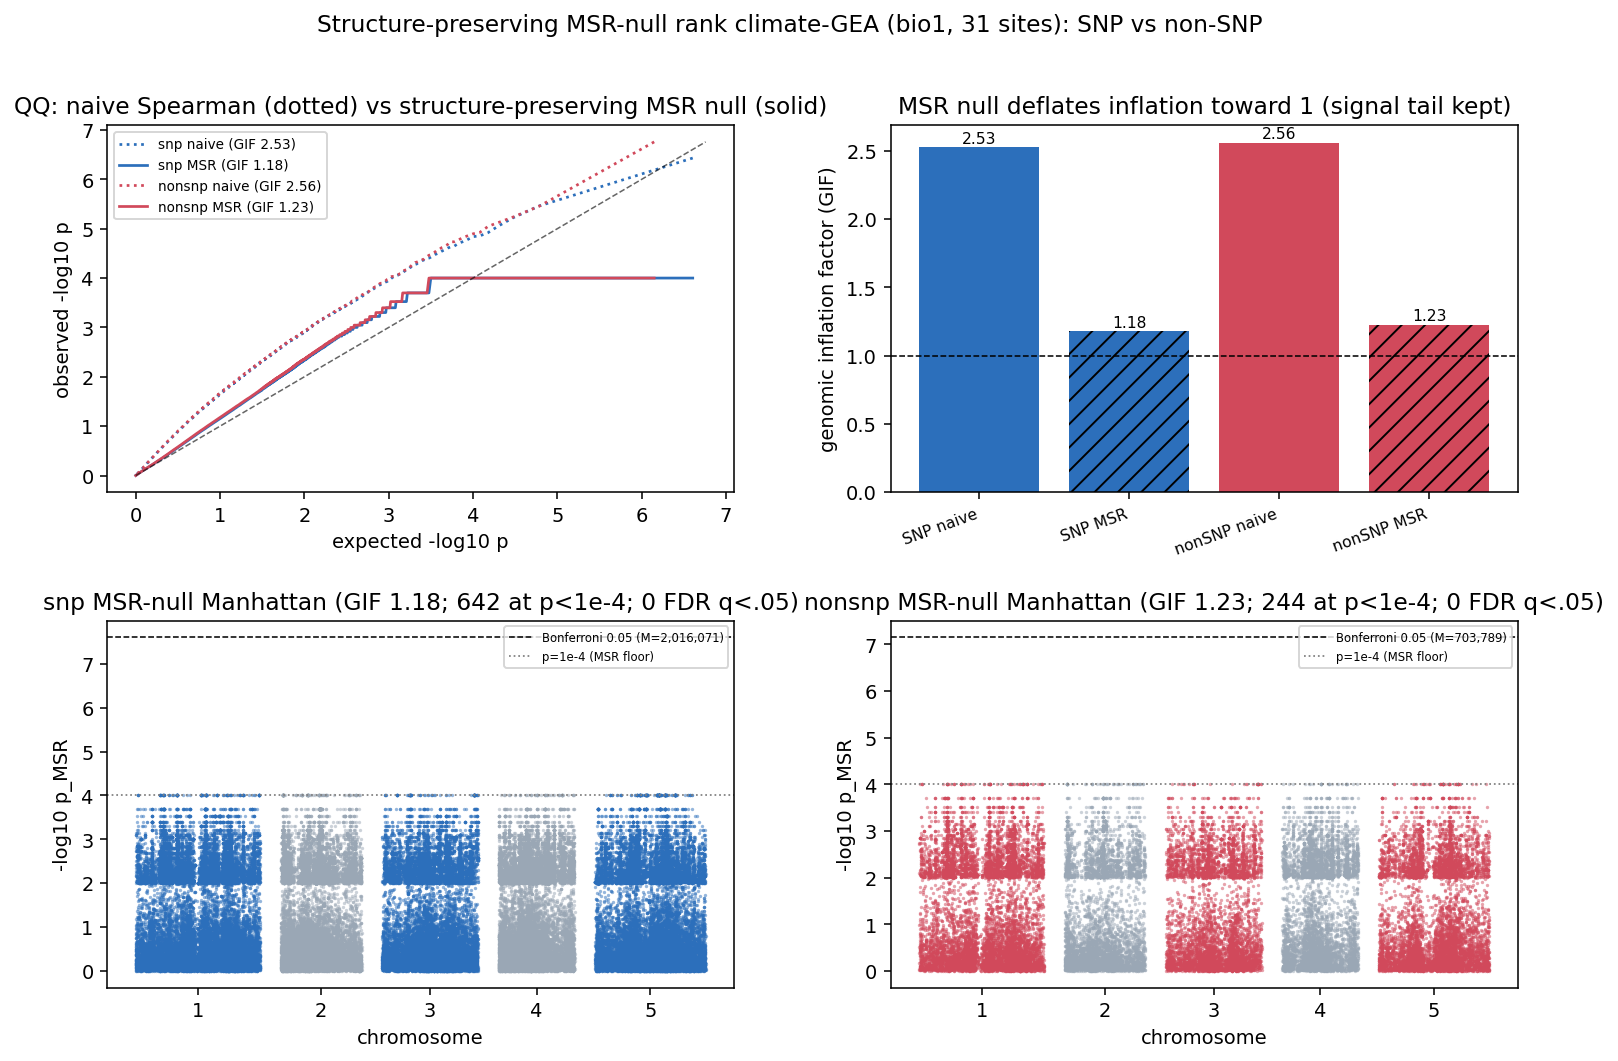

In [3]:
display(Image(filename='/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea_newpanel/msr_kendall/msr_kendall_bio1_figure.png'))

## 3 · Beta-binomial + K=16 latent factors (overdispersion likelihood)
Clearest view of the binomial's real disease: plain binomial+LF (dotted) rockets to −log10p≈**175** (GIF 11.6); beta-binomial+LF (solid) collapses to GIF **2.06** (max≈27). Overdispersion, not structure, was the dominant inflation. 13 SNP / 6 non-SNP Bonferroni — note the towering non-SNP Chr3 peak (−log10p≈13.7).

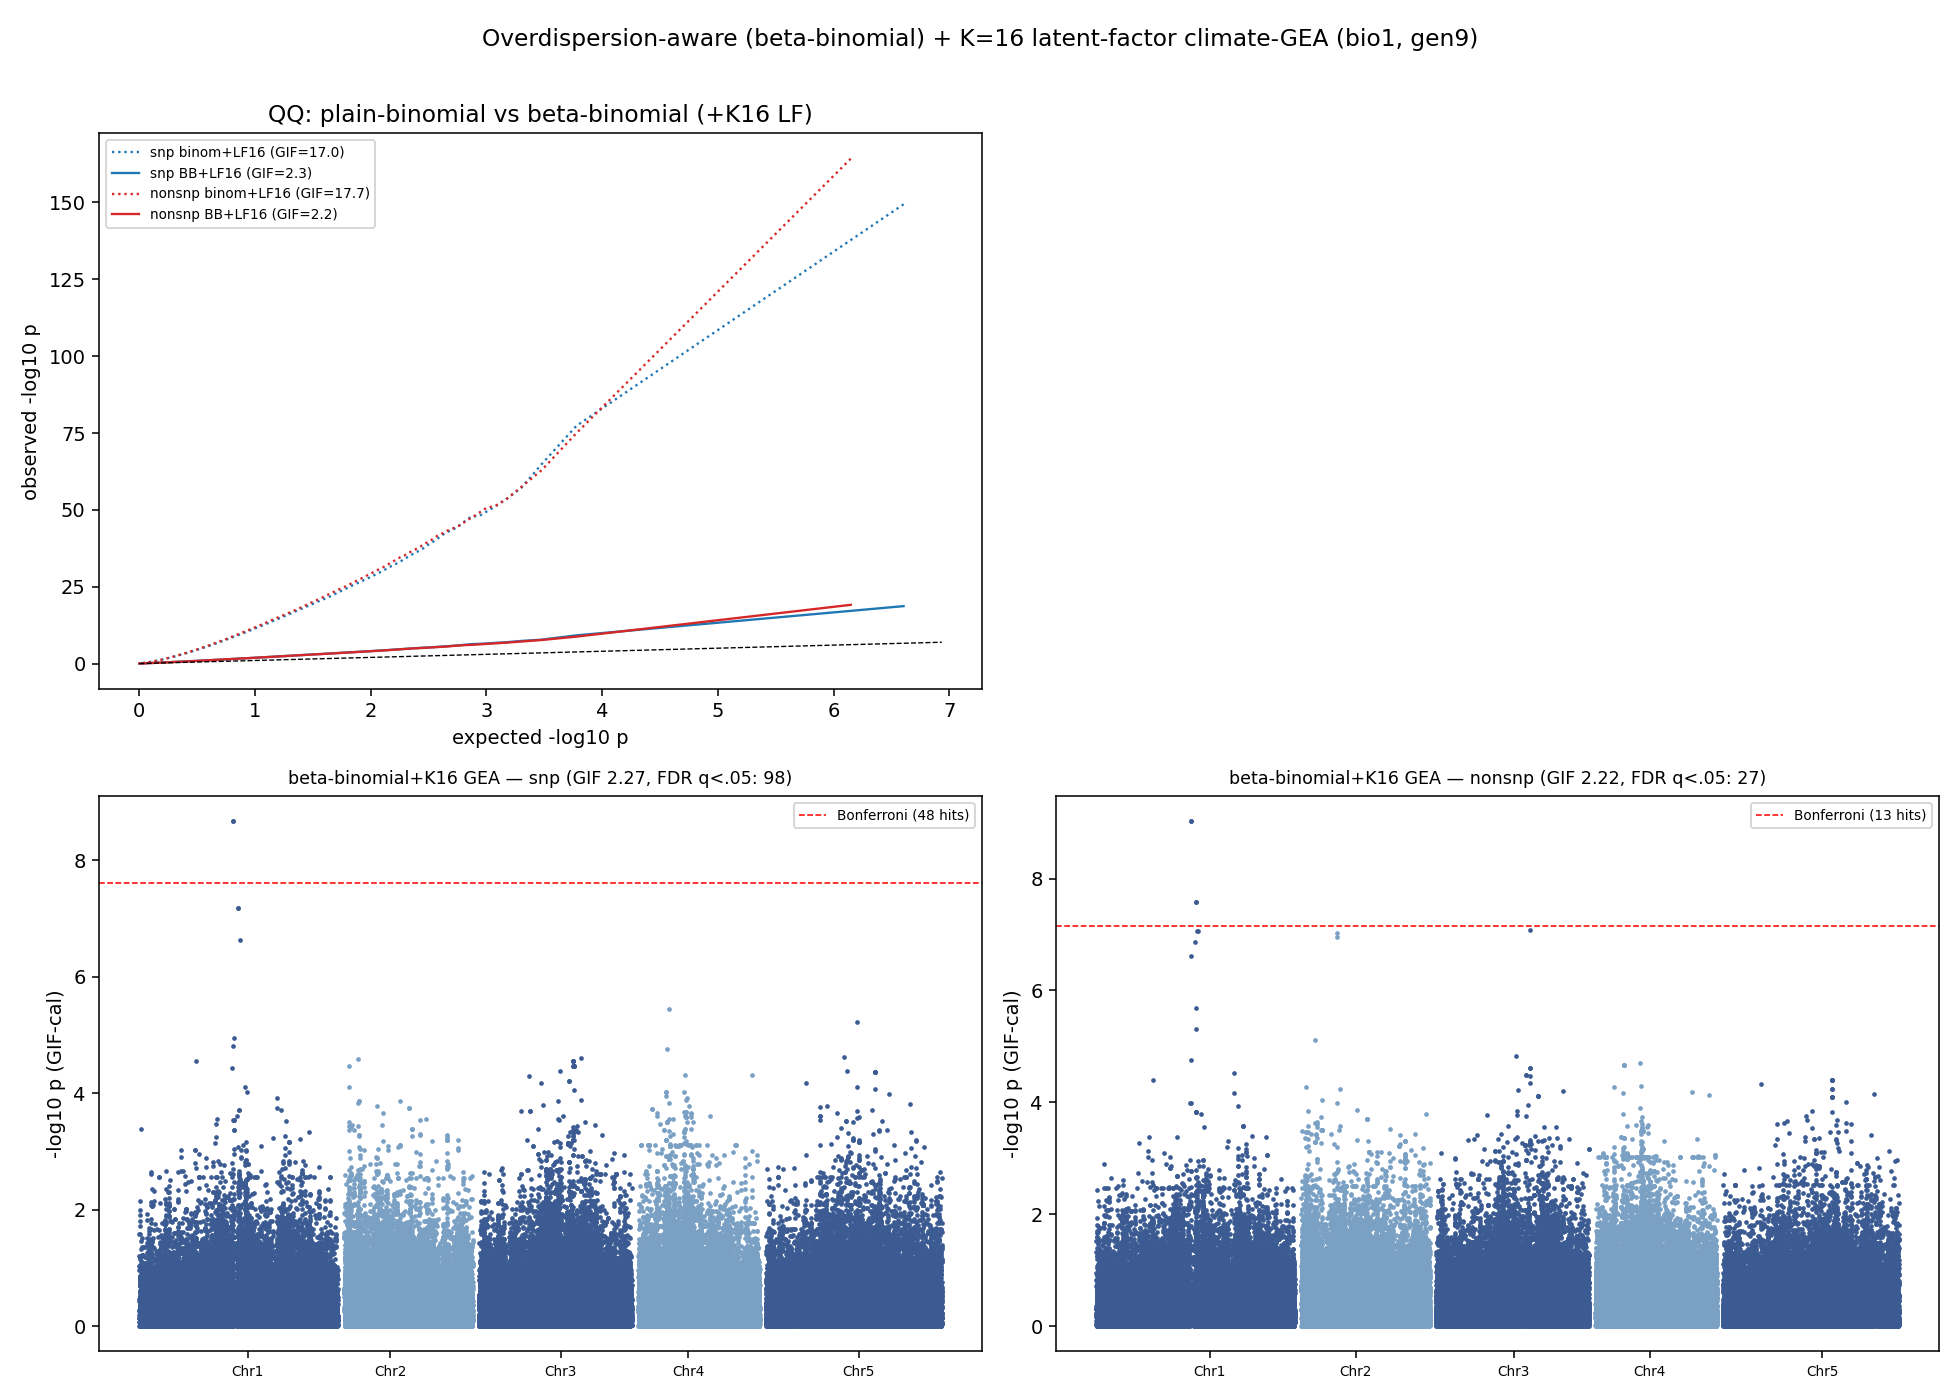

In [4]:
display(Image(filename='/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea_newpanel/betabinom/betabinom_qq_manhattan.png'))

## 4 · Quasi-binomial vs effective-N (overdispersion), QQ
Binomial+LF (grey) is a near-vertical inflation spike; quasi-binomial (blue) → GIF 2.7; **effective-N (red) → GIF 1.17**, essentially on the diagonal — the best-calibrated binomial.

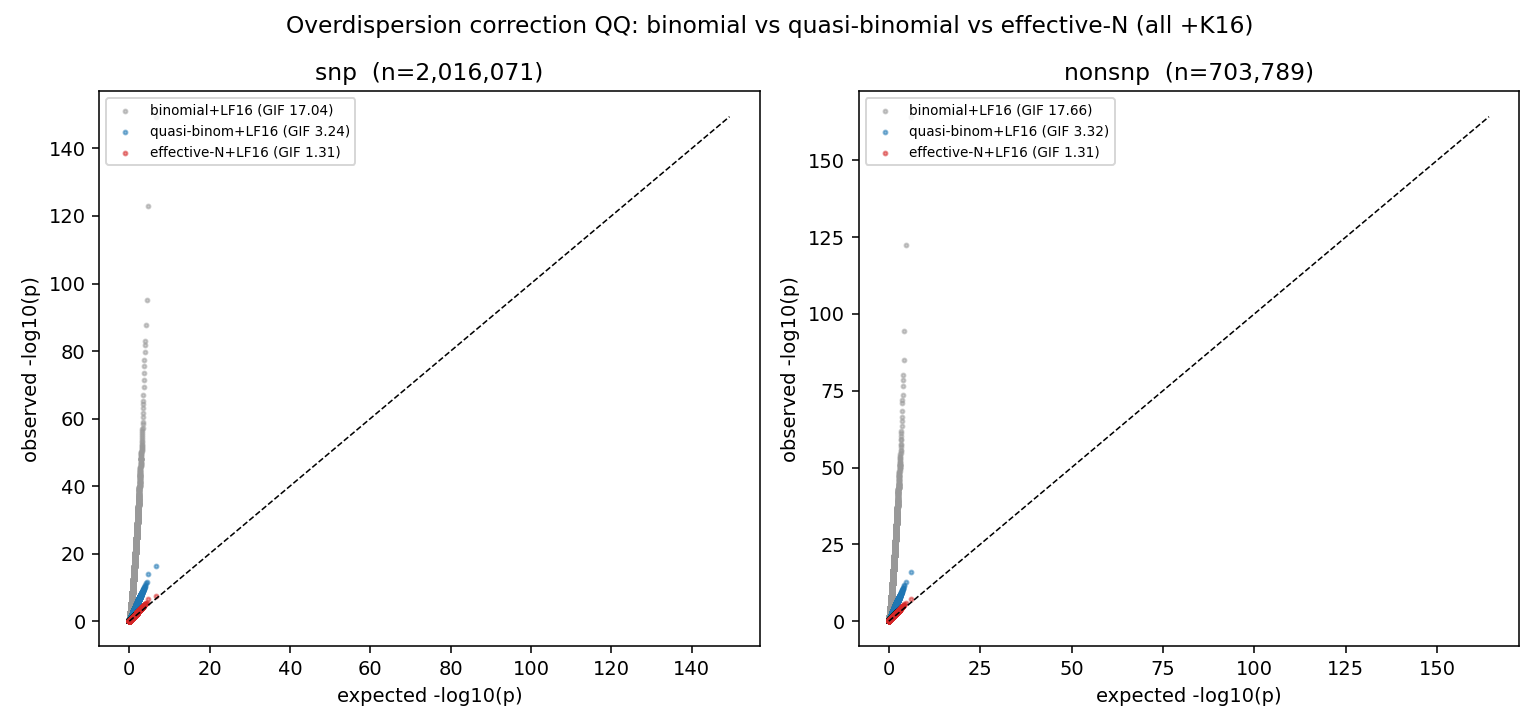

In [5]:
display(Image(filename='/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea_newpanel/quasibinom/qq_quasibinom.png'))

## 5 · Effective-N + K=16 Manhattan (the cleanest baseline)
At GIF≈1.17/1.20 the baseline is flat — but only **1 SNP hit (Chr1) and 0 non-SNP** survive. Effective-N tames inflation best yet nearly empties the signal: the calibration-vs-power trade in one picture.

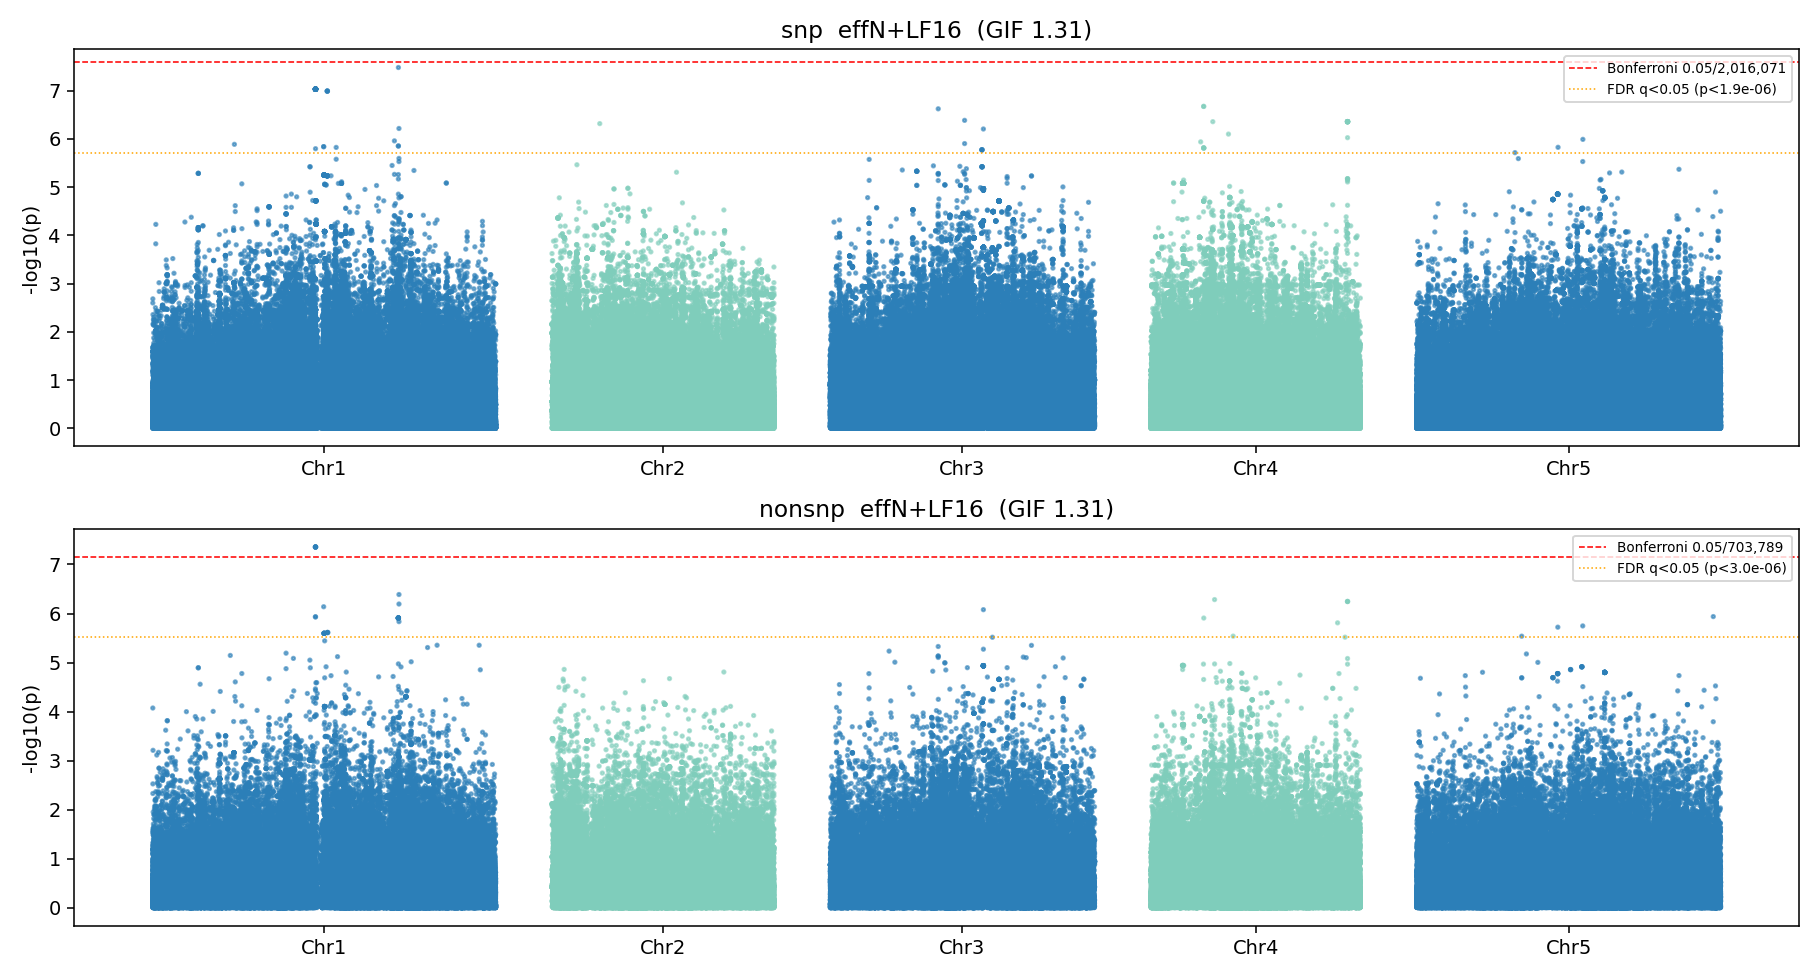

In [6]:
display(Image(filename='/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea_newpanel/quasibinom/manhattan_best.png'))

## Read-out
- **Rank route** (you want the monotone/nonlinear sensitivity): latent-factor partial-Spearman keeps signal but only reaches GIF~2.6; MSR-null Kendall is best-calibrated (1.3) but underpowered at 31 sites.
- **Binomial route:** overdispersion is the bigger disease — beta-binomial (GIF 2.06) and effective-N (GIF 1.17) both fix it; effective-N calibrates best but nearly kills signal.
- **SNP vs non-SNP:** same loci at the (residually inflated) plot level, different loci at the honest MSR unit — trust the latter; non-SNP flags SNP-invisible loci including the LFMM lead.
- Next: the per-axis (bio1..19+pc1) × {SNP, non-SNP, SV, SNP∩SV} significant-block table from the GIF-calibrated latent-factor partial-Spearman.